### Create SMET Forcing Files from Met Station Data: Point Simulation PPSA2

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **rasterio**

In [7]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [8]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

## Open PPSA2 Met Station Data

In [9]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met_raw = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met_raw['datetime'] = pd.to_datetime(df_met_raw['utc_valid'], utc=True)
df_met_raw = df_met_raw.set_index('datetime')

# create a dataframe, df_met, which contains only the datetime, PCIRZZZ, SDIRZZZ, TAIRZZZ, XRIRZZZ
df_met = df_met_raw[['PCIRZZZ', 'SDIRZZZ', 'TAIRZZZ', 'XRIRZZZ']].copy()

# cut to the same datetime as hrrr-ak
df_met = df_met.loc['2024-10-01T05:00':'2025-06-01T00:00']

# remove any PCIRZZZ values that are above 150
df_met['precip_accum_total'] = (df_met['PCIRZZZ'].where(df_met['PCIRZZZ'] <= 150)) * 25.4 # convert from inches to mm

# now, calculate the precipitation rate in mm/hr from the cumulative precip, and then convert to mm/s to compare with the model output
# df_met['precip_rate'] = df_met['precip_accum_total'].diff() / 1 # convert from mm/hr to mm/s (since the data is hourly, diff() gives us the change in precip per hour, so we divide by 1 to get mm/hr, then

# compute diff
diff = df_met["precip_accum_total"].diff()

# detect time gaps
time_diff = df_met.index.to_series().diff().dt.total_seconds()

# mask bad intervals
bad = (
    df_met["precip_accum_total"].isna() |
    df_met["precip_accum_total"].shift(1).isna() |
    (time_diff > 3600)
)

df_met["precip_accum_1hr"] = diff.mask(bad)

# get all the variables consistent first 
df_met['RH'] = df_met['XRIRZZZ']
df_met['HS'] = df_met['SDIRZZZ'] * 2.54 # convert from inches to mm, this is the snow depth in mm

# lightly clean HS so that no values are over 250cm 
df_met['HS'] = df_met['HS'].where(df_met['HS'] < 250, np.nan)

df_met['TA'] = (df_met['TAIRZZZ'] - 32) * 5/9 # convert from F to C
df_met.head()

,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,precip_accum_total,precip_accum_1hr,RH,HS,TA
datetime,,,,,,,,,
2024-10-01 05:00:00+00:00,278.62,17.08,37.2,92.6,NaN,NaN,92.6,43.3832,2.888889
2024-10-01 06:00:00+00:00,278.66,17.28,37.5,93.3,NaN,NaN,93.3,43.8912,3.055556
2024-10-01 07:00:00+00:00,278.66,17.08,38.2,93.8,NaN,NaN,93.8,43.3832,3.444444
2024-10-01 08:00:00+00:00,278.70,16.48,39.1,92.5,NaN,NaN,92.5,41.8592,3.944444
2024-10-01 09:00:00+00:00,278.70,17.28,39.7,91.5,NaN,NaN,91.5,43.8912,4.277778


## Load the HRRR Dataset, 

In [10]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_ppsa2.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

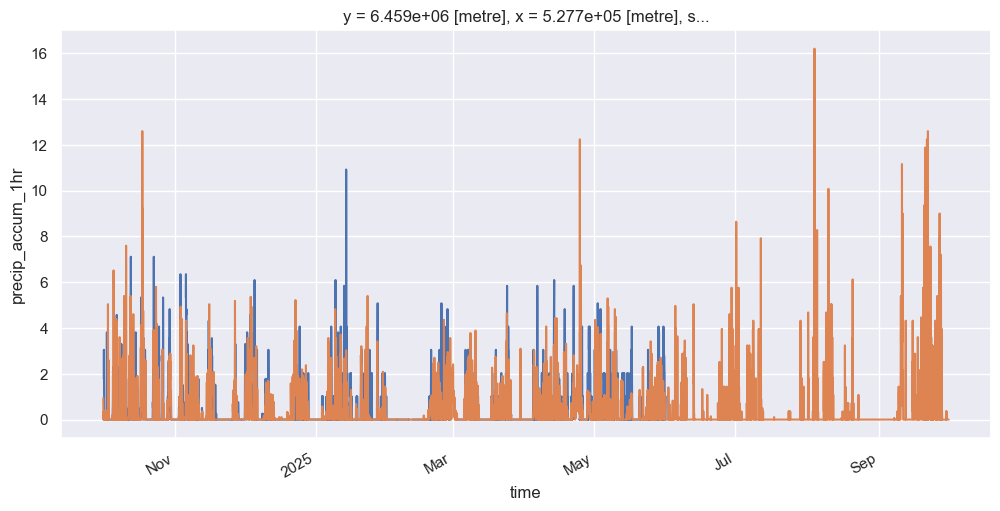

In [11]:
df_met['precip_accum_1hr'].plot()
ds['precip_accum_1hr'].plot()

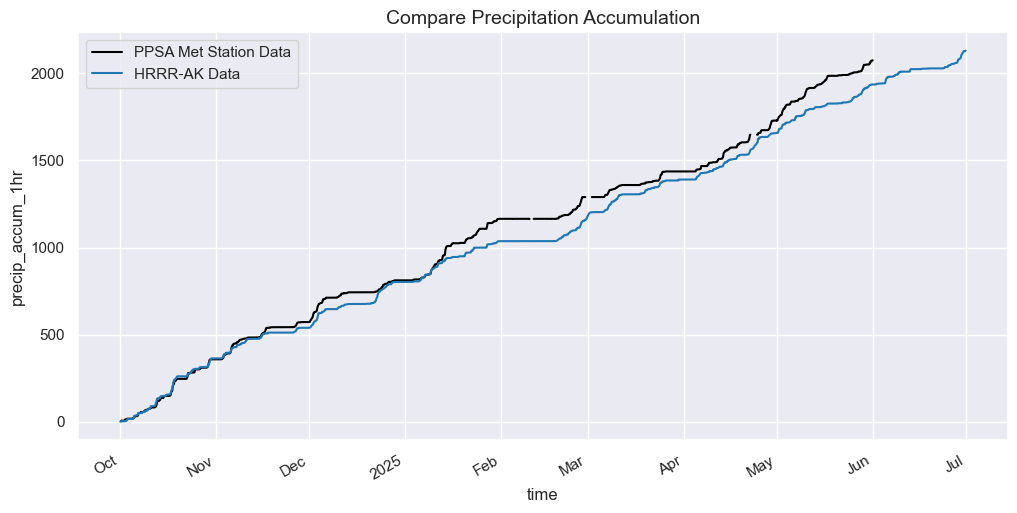

In [32]:
df_met['precip_accum_1hr'].cumsum().plot(label='PPSA Met Station Data', color='black')
ds['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')
plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [12]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

This version dealing with the timestepping, and precipiation units over that timestep

In [13]:
lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

New code, 

df_met time range: 2024-10-01 05:00:00+00:00 to 2025-06-01 00:00:00+00:00
ds time range: 2024-10-01T05:00:00.000000000 to 2025-07-01T00:00:00.000000000
SMET file written to: /home/cassie/python/models/run_snowpack/sites/ppsa2/input/met_hrrrak_ppsa2_WY2025.smet


/tmp/ipykernel_1654892/520590099.py:198: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/home/cassie/programs/miniforge3/envs/rasterio/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  func(*args, **kwargs)
/home/cassie/programs/miniforge3/envs/rasterio/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


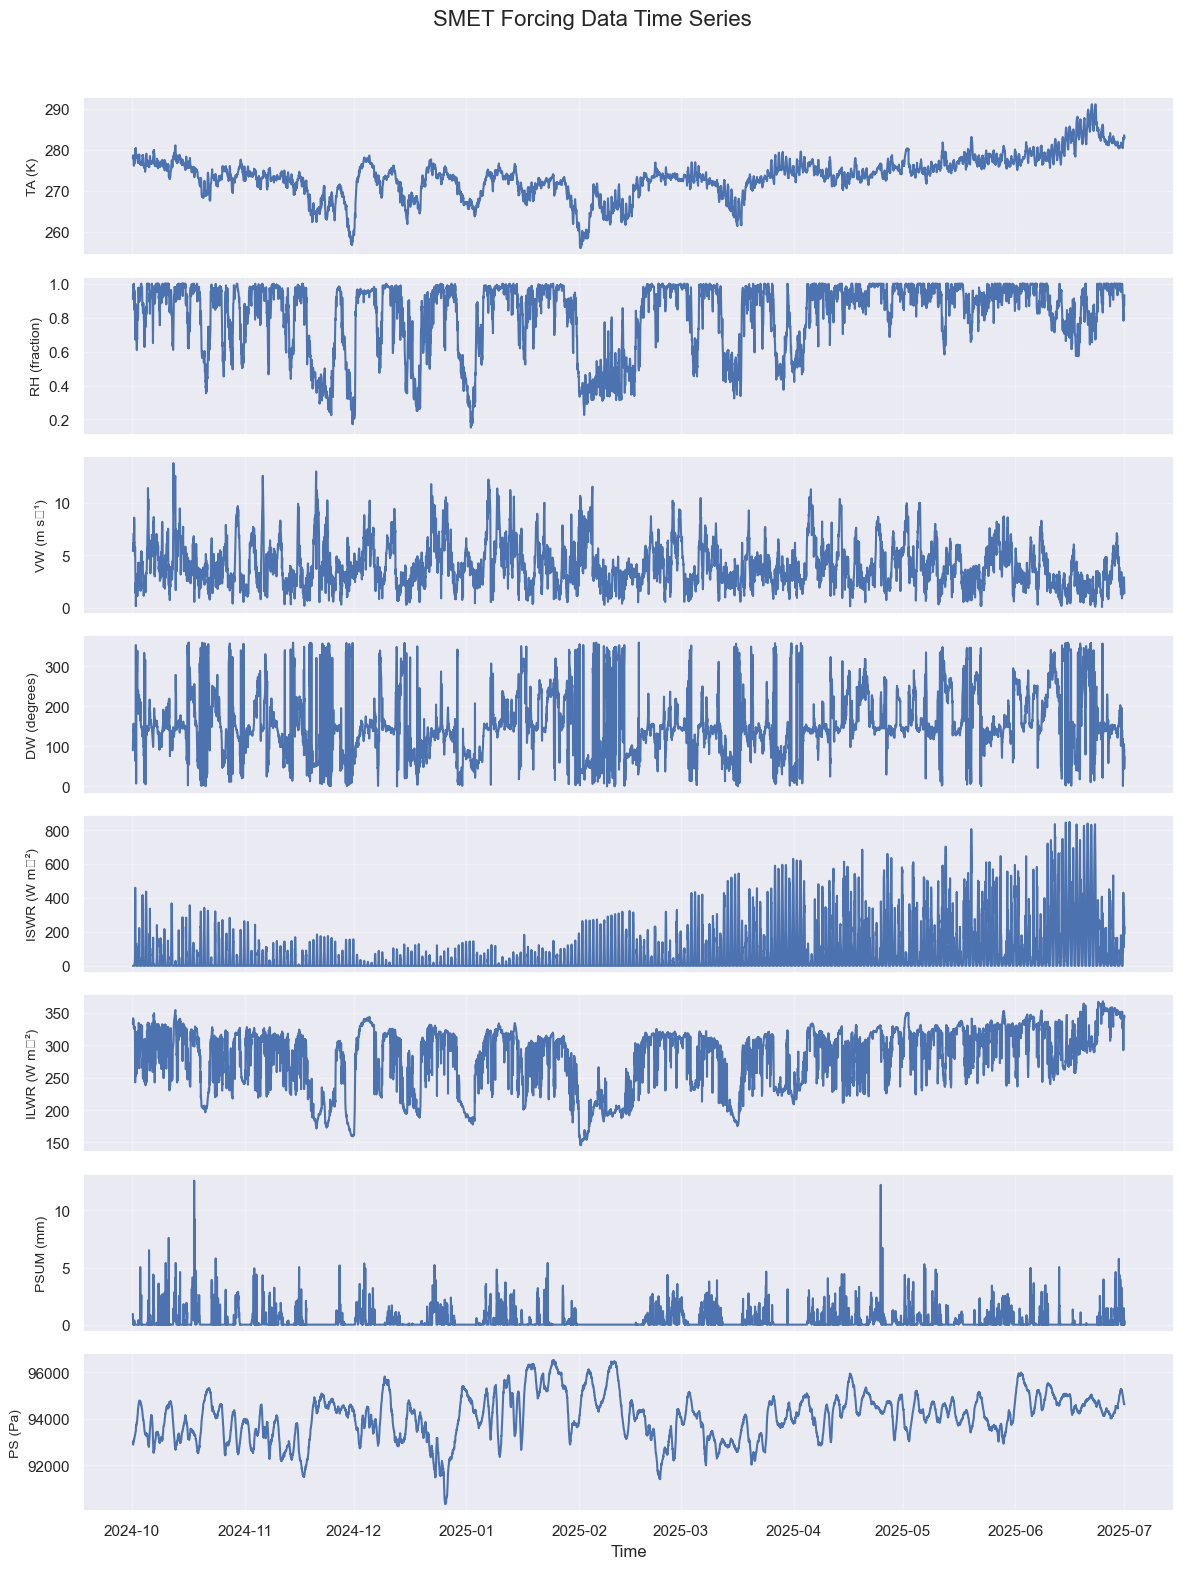

In [18]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# =========================
# SLICE DATASETS TO COMMON TIME RANGE
# =========================
start_time = '2024-10-01T05:00'
end_time = '2025-07-01T00:00'

# Slice df_met (pandas DataFrame)
df_met = df_met.loc[start_time:end_time]

# Slice ds (xarray Dataset)
ds = ds.sel(time=slice(start_time, end_time))

print(f"df_met time range: {df_met.index.min()} to {df_met.index.max()}")
print(f"ds time range: {ds.time.min().values} to {ds.time.max().values}")

# =========================
# UNIT CONVERSIONS AND ALIGNMENT
# =========================
# Convert ds temp from K to C
ds_temp_c = ds['temp'] - 273.15  # Kelvin to Celsius

# Convert ds RH from % to fraction (0-1)
ds_rh_frac = ds['rh'] / 100.0

# Assume df_met precip is already in mm accum over 1hr; ds precip_accum_1hr is also mm accum
# If units differ, add conversions here

# Create a common time index (assume ds.time is the reference)
time_index = pd.to_datetime(ds.time.values)

# =========================
# CREATE FILLED DATAFRAME
# =========================
# Initialize df_filled with ds data as base
df_filled = pd.DataFrame(index=time_index)
df_filled['TA'] = ds_temp_c.values  # Default to ds (C)
df_filled['RH'] = ds_rh_frac.values  # Default to ds (fraction)
df_filled['PSUM'] = ds['precip_accum_1hr'].values  # Default to ds (mm accum)

# Fill with df_met where available (prioritize df_met)
if 'TA' in df_met.columns:
    df_filled['TA'] = df_met['TA'].reindex(time_index).fillna(df_filled['TA'])
if 'RH' in df_met.columns:
    # Convert df_met RH to fraction if it's in %
    rh_met_frac = df_met['RH'] / 100.0 if df_met['RH'].max() > 1 else df_met['RH']
    df_filled['RH'] = rh_met_frac.reindex(time_index).fillna(df_filled['RH'])
if 'precip' in df_met.columns:  # Assuming column name for precip accum
    df_filled['PSUM'] = df_met['precip'].reindex(time_index).fillna(df_filled['PSUM'])

# Now df_filled has df_met prioritized, filled with ds where missing

# =========================
# USER SETTINGS FOR SMET
# =========================
OUTFILE = Path("/home/cassie/python/models/run_snowpack/sites/ppsa2/input/met_hrrrak_ppsa2_WY2025.smet")

STATION_ID = "met_hrrrak_ppsa2_WY2025"
STATION_NAME = "Met Station and HRRR-AK Powder Patch Point Forcing"
LAT = lat_ppsa2  # Define these variables
LON = lon_ppsa2
ELEV = elevation_ppsa2
EPSG = 32608
TZ = 0
NODATA = -999

# -------------------------
# SIMULATION TIMESTEP
# -------------------------
TIMESTEP = "1h"
TIMESTEP_SECONDS = pd.to_timedelta(TIMESTEP).total_seconds()

# =========================
# COORDINATE TRANSFORM
# =========================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
EASTING, NORTHING = transformer.transform(LON, LAT)

# =========================
# BUILD DATAFRAME FOR SMET
# =========================
# Use df_filled as base, add other required variables from ds
df = df_filled.copy()

# Add other variables from ds (assuming they are available)
df["ISWR"] = ds['swrad'].values  # W/m²
df["ILWR"] = ds['lwrad'].values  # W/m²
df["PS"] = ds['pressure'].values  # Pa

# Wind from ds
u = ds['10u'].values
v = ds['10v'].values
df["VW"] = np.sqrt(u**2 + v**2)  # m/s
df["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0  # degrees

# Precipitation: Use PSUM from df_filled (mm accum per timestep)

# =========================
# UNIT CONVERSIONS FOR SMET
# =========================
# Convert TA from C to K (SMET expects Kelvin)
df["TA"] = df["TA"] + 273.15

# RH is already in fraction (0-1)
# VW: m/s
# DW: degrees
# ISWR: W/m²
# ILWR: W/m²
# PSUM: mm per timestep
# PS: Pa

# =========================
# RESAMPLE TO MODEL TIMESTEP
# =========================
mean_vars = ["TA", "RH", "VW", "DW", "ISWR", "ILWR", "PS"]
sum_vars = ["PSUM"]

df_mean = df[mean_vars].resample(TIMESTEP).mean()
df_sum = df[sum_vars].resample(TIMESTEP).sum()
df = pd.concat([df_mean, df_sum], axis=1)

# Replace missing values
df = df.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")
    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")
    f.write("source           = df_met filled with HRRR-AK\n")
    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

print(f"SMET file written to: {OUTFILE}")

# =========================
# PLOT FORCING DATA
# =========================
# Variables to plot (from SMET fields)
variables = ['TA', 'RH', 'VW', 'DW', 'ISWR', 'ILWR', 'PSUM', 'PS']

# Unit labels for y-axes
unit_labels = {
    'TA': 'K',
    'RH': 'fraction',
    'VW': 'm s⁻¹',
    'DW': 'degrees',
    'ISWR': 'W m⁻²',
    'ILWR': 'W m⁻²',
    'PSUM': 'mm',
    'PS': 'Pa'
}

# Create subplots: 8 rows, 1 column
fig, axes = plt.subplots(8, 1, figsize=(12, 16), sharex=True)

for i, var in enumerate(variables):
    ax = axes[i]
    # Plot the variable, excluding NODATA values
    data = df[var].replace(NODATA, np.nan)
    ax.plot(df.index, data, linewidth=1.5)
    ax.set_ylabel(f"{var} ({unit_labels.get(var, '')})", fontsize=10)
    ax.grid(True, alpha=0.3)

# Set common x-label
axes[-1].set_xlabel("Time", fontsize=12)

# Overall title
fig.suptitle("SMET Forcing Data Time Series", fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# # Save the plot
# plot_path = "/home/cassie/python/models/run_snowpack/sites/ppsa2/input/forcing_timeseries_plot.png"
# plt.savefig(plot_path, dpi=300)
# plt.show()

# print(f"Forcing data plot saved to: {plot_path}")

### Plot all the different precipiation variables together

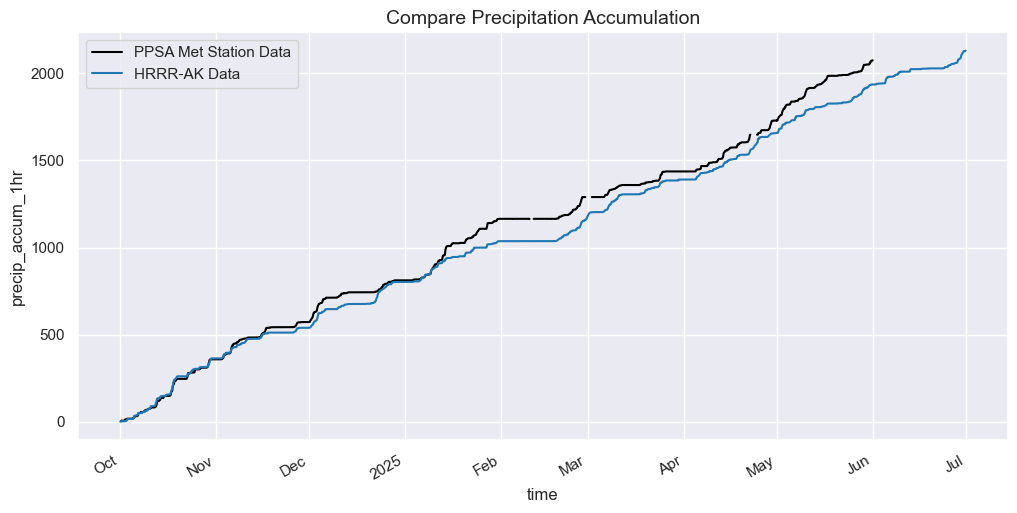

In [35]:
df_met['precip_accum_1hr'].cumsum().plot(label='PPSA Met Station Data', color='black')
ds['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')
plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

In [36]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ASSUMPTIONS
# =========================
# df_met: pandas DataFrame with datetime index and 'precip_accum_1hr' column (mm accum 1hr)
# ds: xarray Dataset with 'time' coord and 'precip_accum_1hr' variable (mm accum 1hr)
# Both are already sliced to the common time range (e.g., '2024-10-01T05:00' to '2025-07-01T00:00')

# =========================
# CREATE FILLED PRECIP COLUMN IN df_met
# =========================
# Get common time index from ds
time_index = pd.to_datetime(ds.time.values)

# Reindex df_met precip to ds time index, filling NaNs with ds values
df_met['precip_accum_1hr_filled_with_hrrr'] = df_met['precip_accum_1hr'].reindex(time_index).fillna(ds['precip_accum_1hr'].values)

# =========================
# PLOT PRECIPITATION COMPARISON
# =========================
# Plot cumulative sums
plt.figure(figsize=(12, 6))

df_met['precip_accum_1hr'].cumsum().plot(label='PPSA Met Station Data', color='black', linewidth=1.5)
ds['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue', linewidth=1.5)
df_met['precip_accum_1hr_filled_with_hrrr'].cumsum().plot(label='Filled with HRRR Data', color='red', linewidth=1.5)

plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.ylabel('Cumulative Precipitation (mm)', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "ndarray"